<a href="https://colab.research.google.com/github/Nkengfack/Bank_marketing_ml_Classifications/blob/main/bank_marketing_ML_perfomance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Data Science Final Project — University of Hertfordshire
## Bank Term Deposit Subscription Prediction
### A Comparative Performance Analysis of Machine Learning Models


---

### Part 1: Data Loading, Inspection & Exploratory Data Analysis (EDA)

- Loading and inspecting the Bank Marketing dataset
- Identifying duplicates, unknown values, and the pdays anomaly
- Summary statistics, class distribution, and feature distributions
- Correlation analysis and outlier detection

## Cell 1 — Import Libraries

In [49]:
# Loading all the tools this project depends on before anything else.
# These libraries handle data loading, manipulation, visualisation,
# and will also support the modelling work in later parts.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Show all columns and round floats to 2 decimal places for cleaner output
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent visual style across every chart in this notebook
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Project colour scheme — defined once and reused across all charts
COLOUR_NO  = '#2ca02c'   # green  — clients who did not subscribe
COLOUR_YES = '#D85A30'   # coral — clients who subscribed
PALETTE    = [COLOUR_NO, COLOUR_YES]

# Target column name defined once so it is easy to change if needed
TARGET = 'subscribed'

print('All libraries imported and settings configured successfully.')

All libraries imported and settings configured successfully.


## Cell 2 — Load the Dataset from GitHub

> The file uses a **semicolon** (`;`) as its separator, not a comma. Without `sep=';'` all 21 columns would collapse into one unusable column.

In [50]:
# Loading directly from GitHub means the notebook runs correctly
# from any machine without needing a local copy of the file.

URL = ('https://raw.githubusercontent.com/Nkengfack/Bank_marketing_ml_Classifications/refs/heads/main/bank_marketing_dataset.csv')

marketing = pd.read_csv(URL, sep=';')

# The original target column is called 'y' in the UCI dataset.
# Renaming it makes the code easier to follow throughout.
marketing.rename(columns={'y': TARGET}, inplace=True)

print(f'Dataset loaded successfully from GitHub.')
print(f'Rows     : {marketing.shape[0]:,}')
print(f'Columns  : {marketing.shape[1]}')
print(f'Features : {marketing.shape[1] - 1}  (excluding target column)')
print(f'Target   : {TARGET}  (yes = subscribed,  no = did not subscribe)')
print(f'\nColumn names:')
print(marketing.columns.tolist())

Dataset loaded successfully from GitHub.
Rows     : 41,188
Columns  : 21
Features : 20  (excluding target column)
Target   : subscribed  (yes = subscribed,  no = did not subscribe)

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed']


## Cell 3 — First Look at the Data

Always the first thing to run after loading — confirms the file loaded correctly and the values look sensible.

In [51]:
marketing.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


## Cell 4 — Data Types and Structure

Shows the data type of every column and how many non-null values exist. This is the first check for missing data.

In [52]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Cell 5 — Summary Statistics (Numerical Columns)

This output becomes **Figure 3.1** in the report. Pay attention to columns where max is far above the 75th percentile — that gap usually signals outliers.

In [53]:
print('Summary Statistics — Numerical Features (Figure 3.1)')
print('=' * 60)
marketing.describe()

Summary Statistics — Numerical Features (Figure 3.1)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


## Cell 6 — Summary Statistics (Categorical Columns)

`include='object'` extends describe() to text columns. The `top` row shows the most frequent value. Notice `unknown` appearing in several columns.

In [54]:
print('Summary Statistics — Categorical Features')
print('=' * 60)
marketing.describe(include='object')

Summary Statistics — Categorical Features


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


## Cell 7 — Detecting Hidden Missing Values

This dataset has no NaN values, which looks clean on the surface. However several columns use the string `unknown` as a placeholder which behaves exactly like a missing value but is invisible to `isnull()`.

In [55]:
print('Columns containing unknown values')
print('=' * 60)

unknown_summary = {}

for col in marketing.columns:
    if col == TARGET:
        continue
    try:
        count = (marketing[col] == 'unknown').sum()
        pct   = round(count / len(marketing) * 100, 2)
        if count > 0:
            unknown_summary[col] = {
                'Unknown Count' : count,
                'Unknown (%)'   : pct}
    except TypeError:
        continue

if unknown_summary:
    unknown_df = pd.DataFrame(unknown_summary).T
    print(unknown_df.to_string())
    print(f'\nTotal unknown entries across all columns: '
          f'{unknown_df["Unknown Count"].sum():,.0f}')
else:
    print('No columns contain the string "unknown".')

print('\nNote: default has the highest proportion at over 20%.')
print('These will be kept as a separate category during preprocessing')
print('rather than dropped, to avoid losing too many records.')

Columns containing unknown values
           Unknown Count  Unknown (%)
job               330.00         0.80
marital            80.00         0.19
education        1731.00         4.20
default          8597.00        20.87
housing           990.00         2.40
loan              990.00         2.40

Total unknown entries across all columns: 12,718

Note: default has the highest proportion at over 20%.
These will be kept as a separate category during preprocessing
rather than dropped, to avoid losing too many records.


## Cell 9 — Removing Duplicate Records

Duplicate rows skew distributions and bias model training. Removing them before producing EDA charts keeps everything accurate.

In [56]:
duplicates_found = marketing.duplicated().sum()
print(f'Duplicate rows found: {duplicates_found}')

marketing.drop_duplicates(keep='first', ignore_index=True, inplace=True)
print(f'Duplicates removed.')
print(f'Dataset now has {len(marketing):,} rows.')

Duplicate rows found: 12
Duplicates removed.
Dataset now has 41,176 rows.


## Cell 10 — Classify Columns by Type

Separating columns into numerical and categorical lists here once so they can be reused cleanly throughout the rest of the notebook.

In [57]:
num_features = marketing.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

cat_features = [
    col for col in
    marketing.select_dtypes(include='object').columns.tolist()
    if col != TARGET]

print(f'Numerical features ({len(num_features)}):')
for col in num_features:
    print(f'  {col}')

print(f'\nCategorical features ({len(cat_features)}):')
for col in cat_features:
    print(f'  {col}')

print(f'\nTarget column: {TARGET}  (binary — yes / no)')

Numerical features (10):
  age
  duration
  campaign
  pdays
  previous
  emp.var.rate
  cons.price.idx
  cons.conf.idx
  euribor3m
  nr.employed

Categorical features (10):
  job
  marital
  education
  default
  housing
  loan
  contact
  month
  day_of_week
  poutcome

Target column: subscribed  (binary — yes / no)


## Cell 11 — Target Variable: Class Distribution (Figure 3.2)

The most important early finding in the entire EDA. The class imbalance visible here motivates SMOTE, the metric selection, and the pipeline design in Part 2.

Target Variable — Class Distribution
            Count  Percentage (%)
subscribed                       
no          36537           88.73
yes          4639           11.27


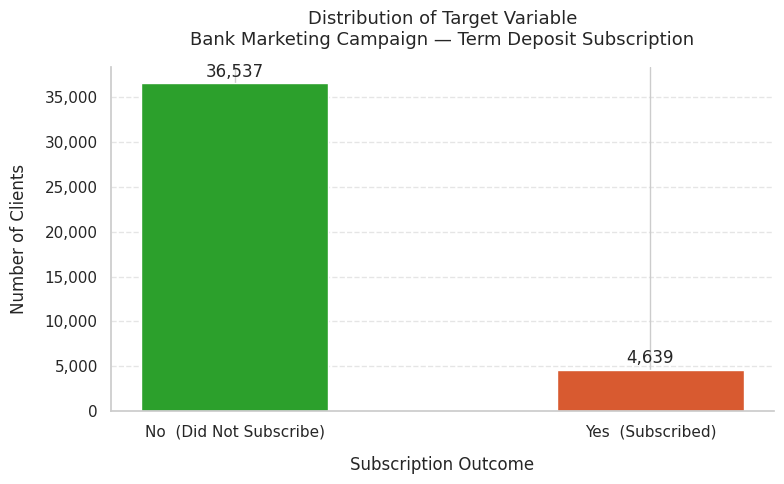


Class imbalance: 88.7% no  vs  11.3% yes
This imbalance will be addressed using SMOTE in Part 2.


In [58]:
counts = marketing[TARGET].value_counts()
pcts   = marketing[TARGET].value_counts(normalize=True) * 100

print('Target Variable — Class Distribution')
print('=' * 45)
print(pd.DataFrame({ 'Count': counts, 'Percentage (%)' : pcts.round(2)}))

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ['No  (Did Not Subscribe)', 'Yes  (Subscribed)'],
    counts.values,
    color=PALETTE,
    width=0.45,
    edgecolor='white')

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 280,
        f'{bar.get_height():,}',
        ha='center', va='bottom',
        fontsize=12, fontweight='medium')

plt.title(
    'Distribution of Target Variable\n'
    'Bank Marketing Campaign — Term Deposit Subscription',
    pad=16, fontsize=13
)
plt.xlabel('Subscription Outcome', labelpad=12)
plt.ylabel('Number of Clients', labelpad=12)
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_3_2_class_distribution.png', dpi=300)
plt.show()

print(f"\nClass imbalance: {pcts['no']:.1f}% no  vs  {pcts['yes']:.1f}% yes")
print('This imbalance will be addressed using SMOTE in Part 2.')

## Cell 12 — Distribution of Numerical Features

A histogram with KDE curve for each numerical feature individually. Each chart is saved as its own PNG file for use in the report. The skewness annotation flags features that may need special handling during preprocessing.

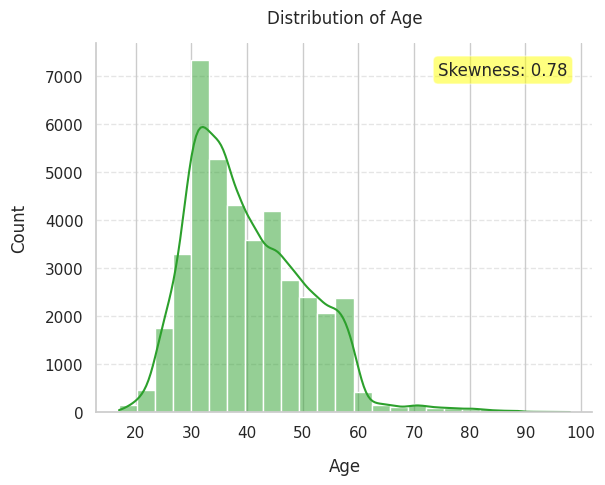

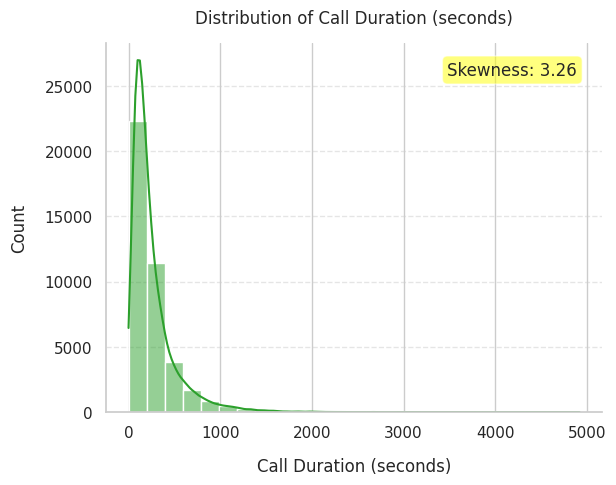

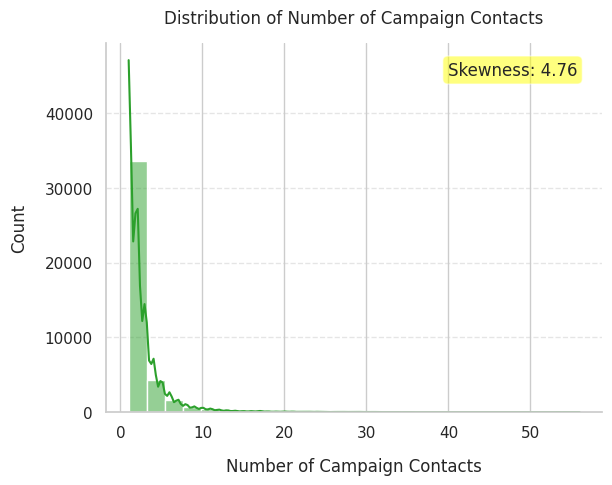

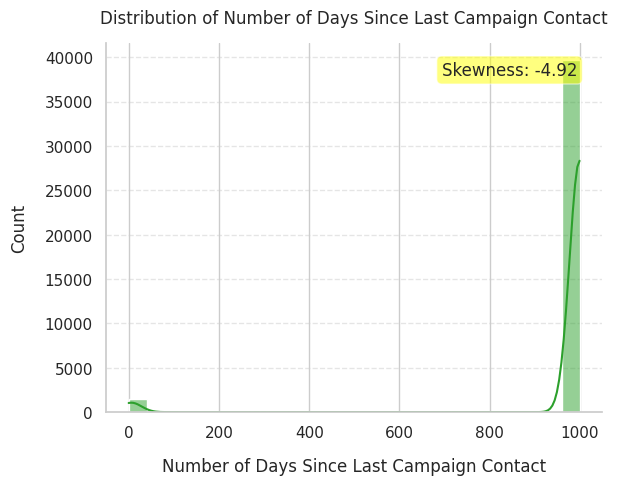

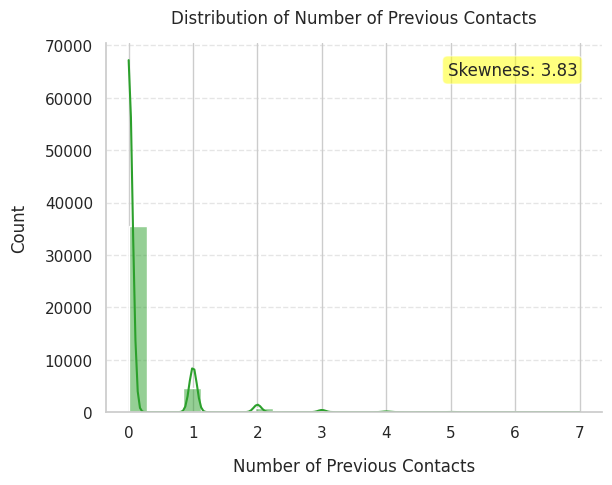

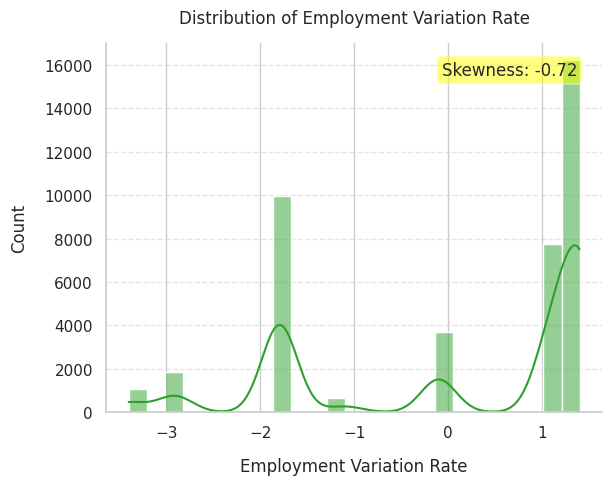

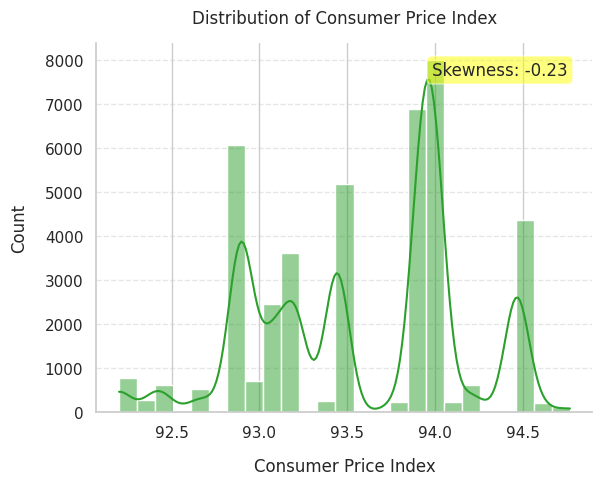

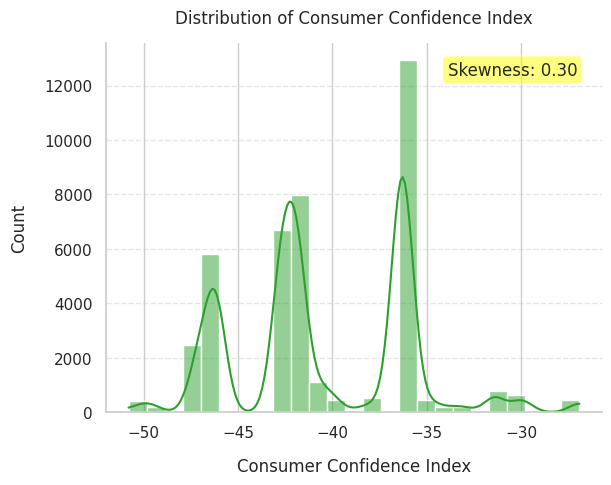

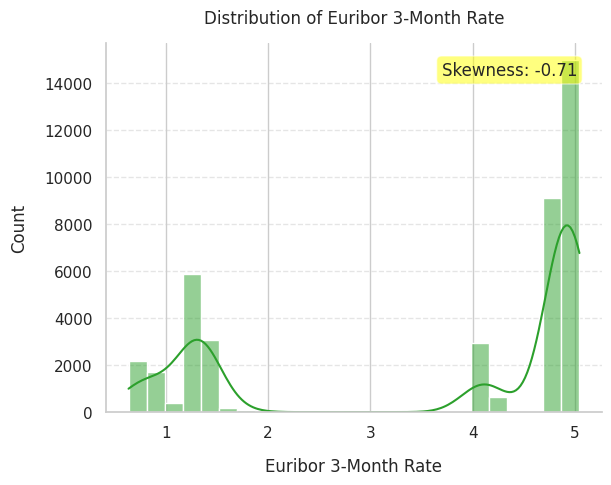

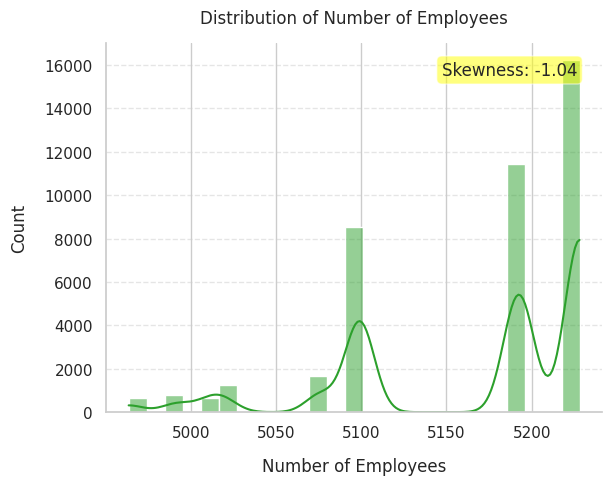

In [59]:
# Friendly display names for chart titles and filenames
feature_names = {
    'age'        : 'Age',
    'duration'      : 'Call Duration (seconds)',
    'campaign'       : 'Number of Campaign Contacts',
    'pdays'       : 'Number of Days Since Last Campaign Contact',
    'previous'      : 'Number of Previous Contacts',
    'emp.var.rate'   : 'Employment Variation Rate',
    'cons.price.idx' : 'Consumer Price Index',
    'cons.conf.idx'  : 'Consumer Confidence Index',
    'euribor3m'     : 'Euribor 3-Month Rate',
    'nr.employed'   : 'Number of Employees'
}

# Redefine here to reflect the current state of the DataFrame
num_features = marketing.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

for col in num_features:
    fig, ax = plt.subplots()

    sns.histplot(marketing[col], kde=True, bins=25, color=COLOUR_NO)

    # .get(col, col) falls back to the raw column name if not in dictionary
    plt.title(f'Distribution of {feature_names.get(col, col)}', pad=14)
    plt.text(
        0.95, 0.95,
        f'Skewness: {marketing[col].skew():.2f}',
        transform=ax.transAxes,
        horizontalalignment='right',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
    )
    plt.xlabel(feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(f'Distribution of {feature_names.get(col, col)}.png', dpi=300)
    plt.show()

    print('\n')

## Cell 13 — Distribution of Categorical Features

A count plot for each categorical feature individually, sorted from most to least frequent. Bars are labelled with counts for easy reading in the report.

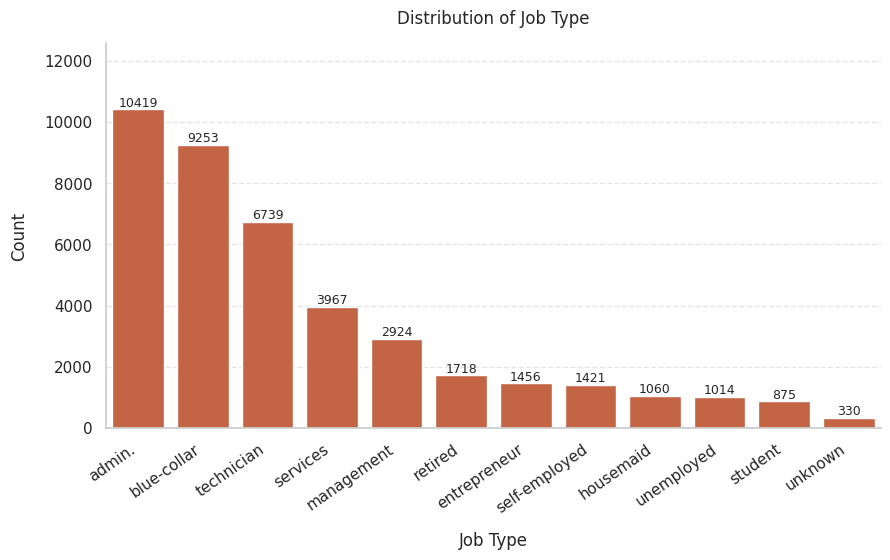

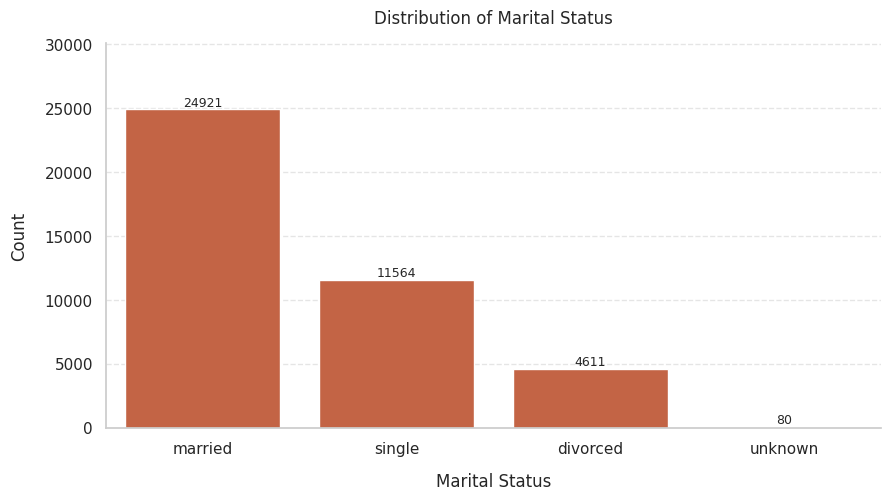

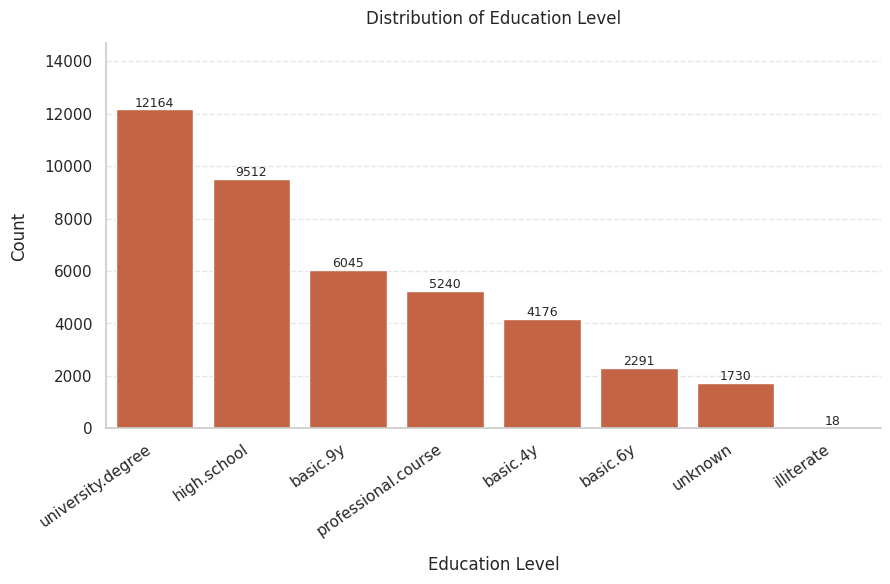

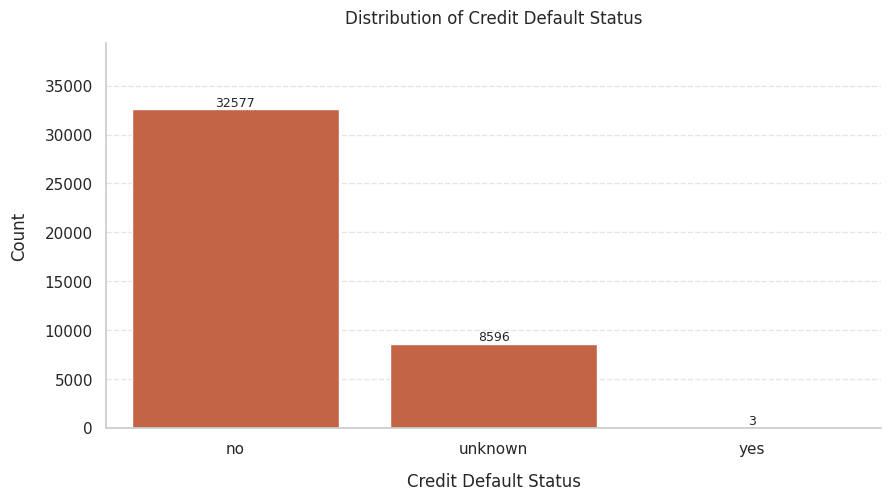

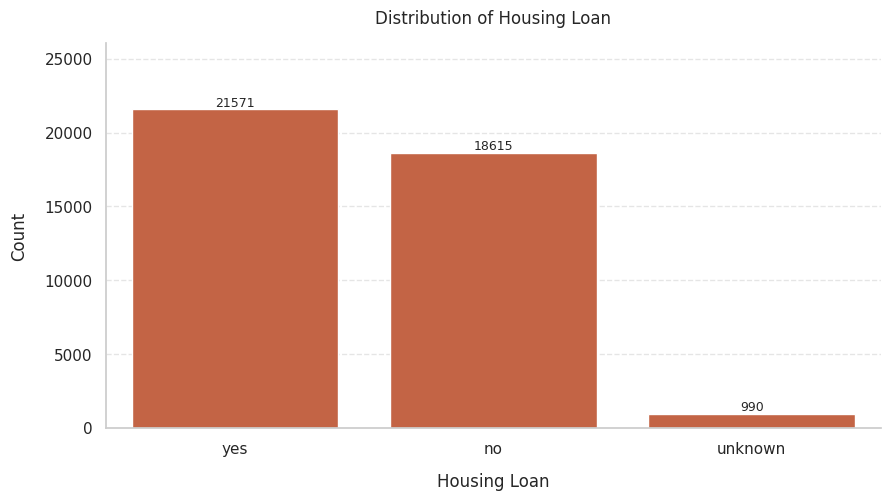

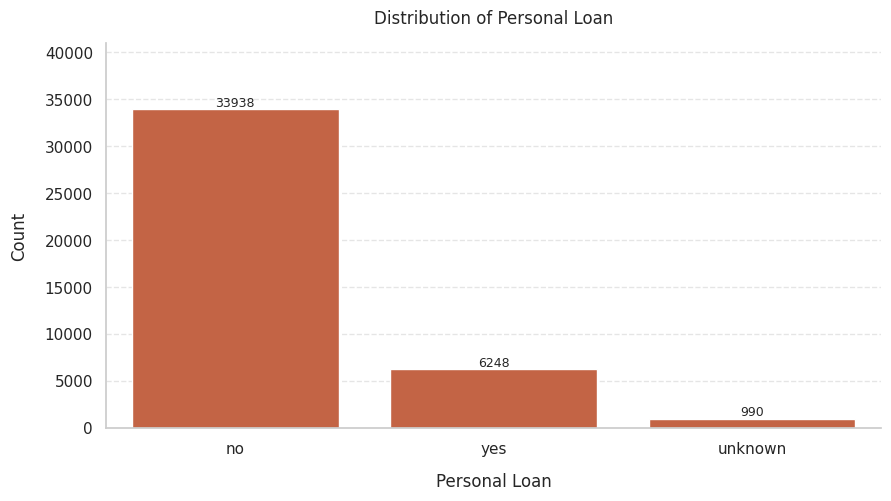

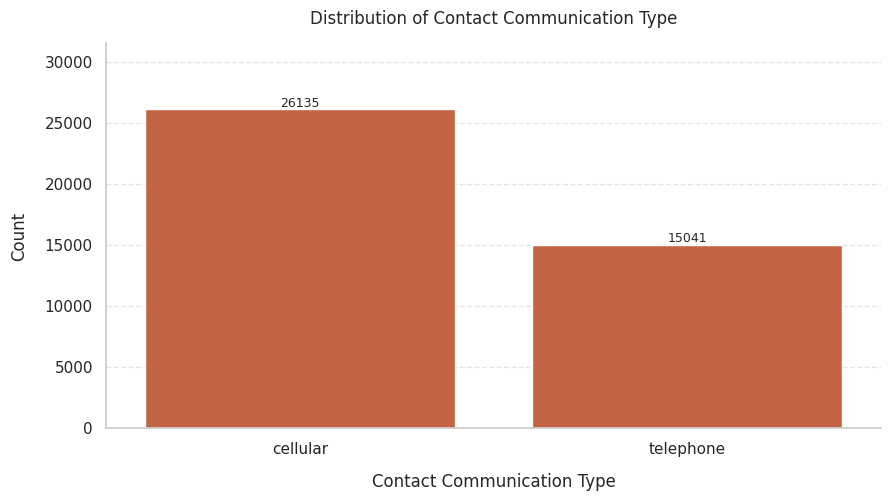

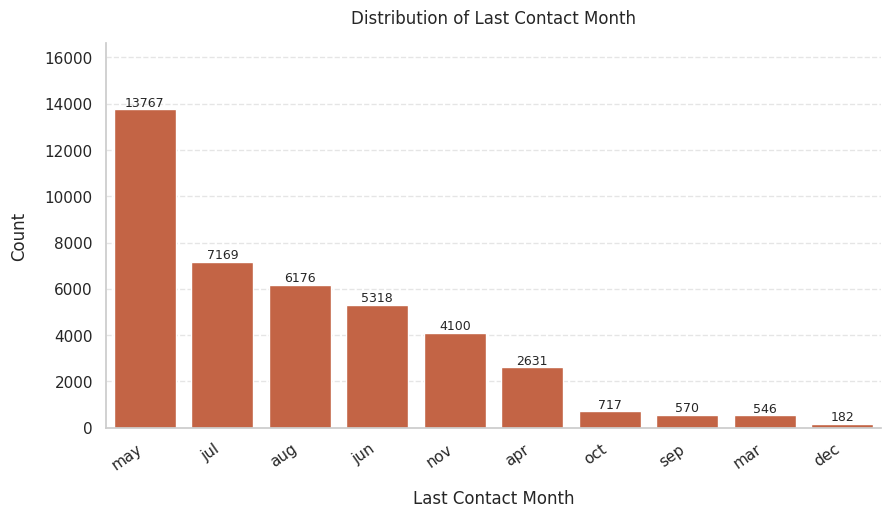

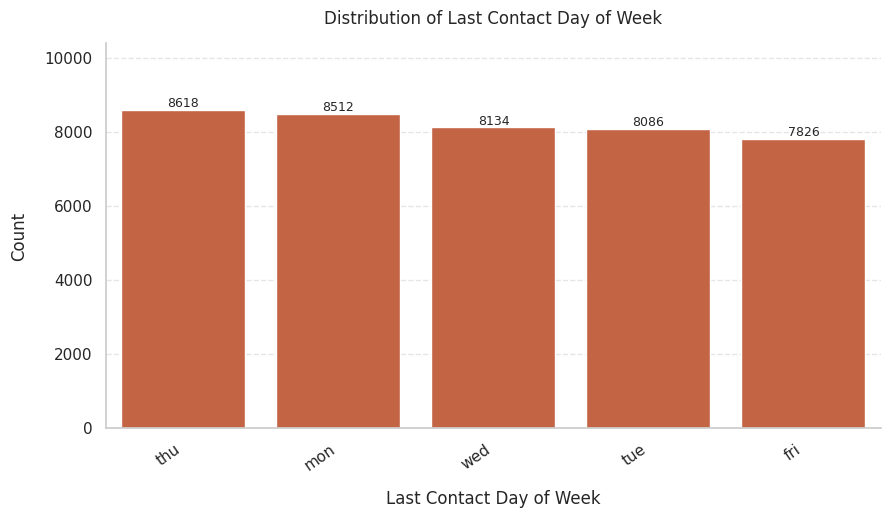

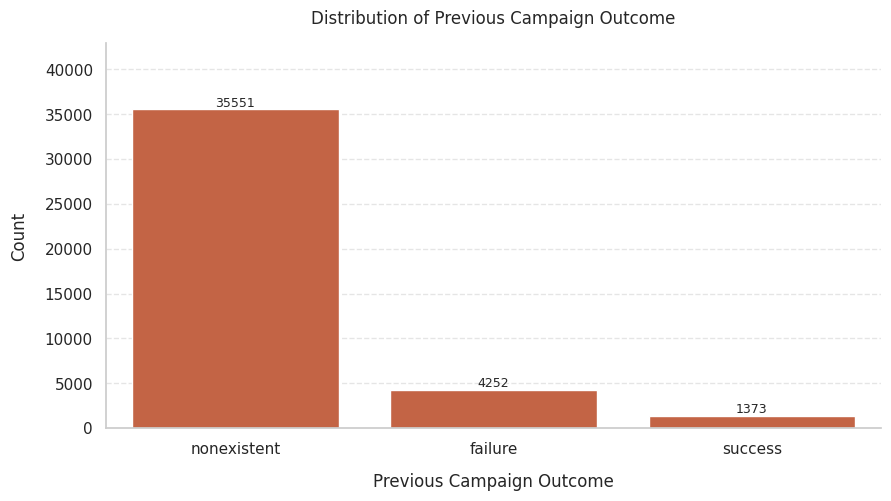

In [60]:
# Friendly display names — reused in Cell 14 as well
cat_feature_names = {
    'job'         : 'Job Type',
    'marital'   : 'Marital Status',
    'education'   : 'Education Level',
    'default'     : 'Credit Default Status',
    'housing'    : 'Housing Loan',
    'loan'        : 'Personal Loan',
    'contact'   : 'Contact Communication Type',
    'month'       : 'Last Contact Month',
    'day_of_week' : 'Last Contact Day of Week',
    'poutcome'    : 'Previous Campaign Outcome'}

for col in cat_features:
    fig, ax = plt.subplots(figsize=(10, 5))

    order = marketing[col].value_counts().index

    sns.countplot(data=marketing, x=col, order=order, color=COLOUR_YES, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)

    plt.title(f'Distribution of {cat_feature_names.get(col, col)}', pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Count', labelpad=12)
    plt.ylim(0, ax.get_ylim()[1] * 1.15)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(
        f'Distribution of {cat_feature_names.get(col, col)}.png',
        dpi=300)
    plt.show()

    print('\n')

## Cell 14 — Subscription Rate by Key Categorical Features

For each key categorical feature, this chart shows what percentage of clients in each category subscribed. More informative than raw counts because it shows which categories are most associated with a positive outcome.

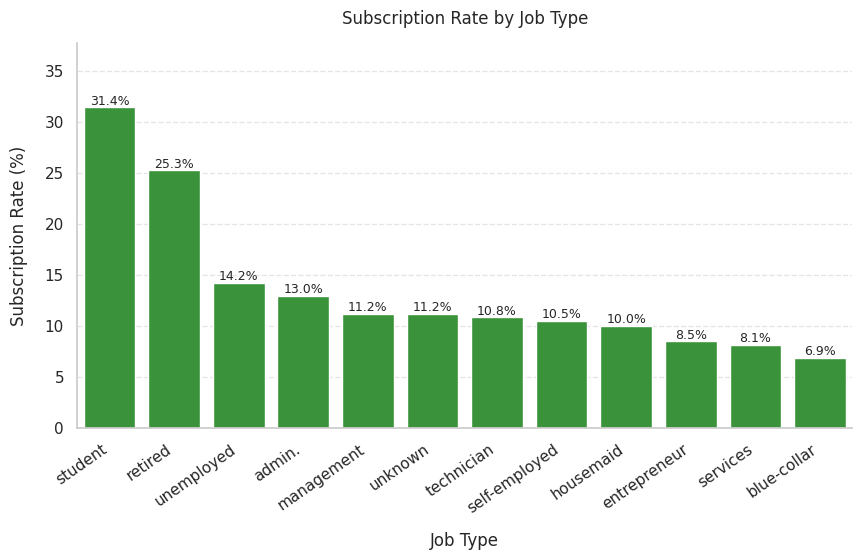

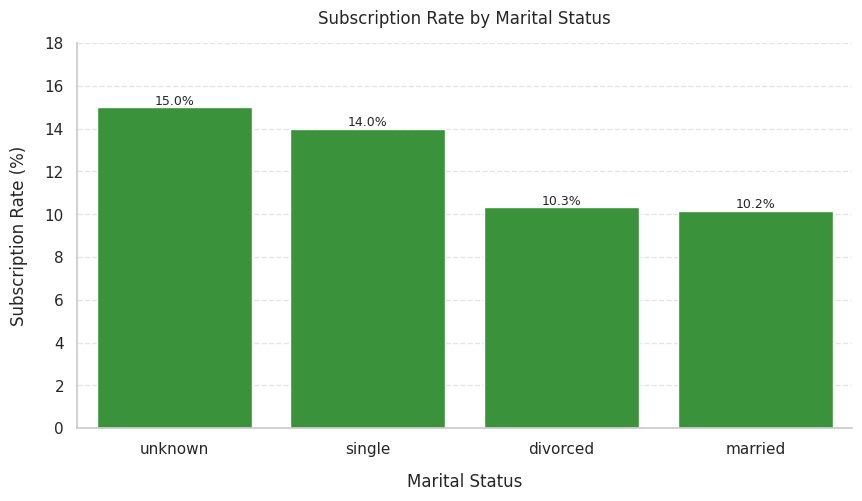

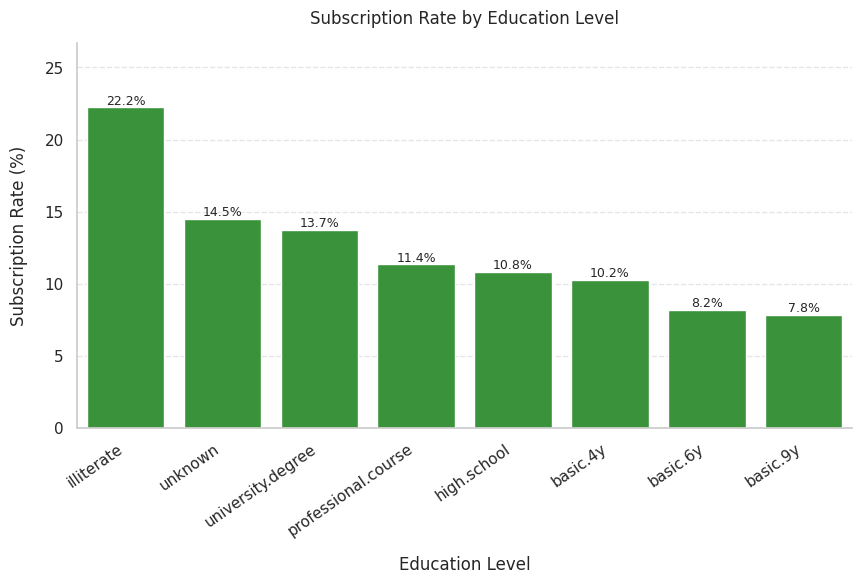

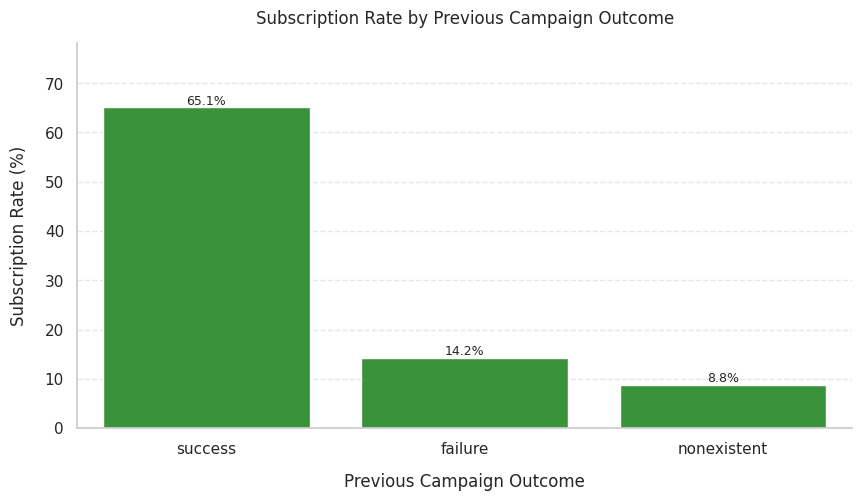

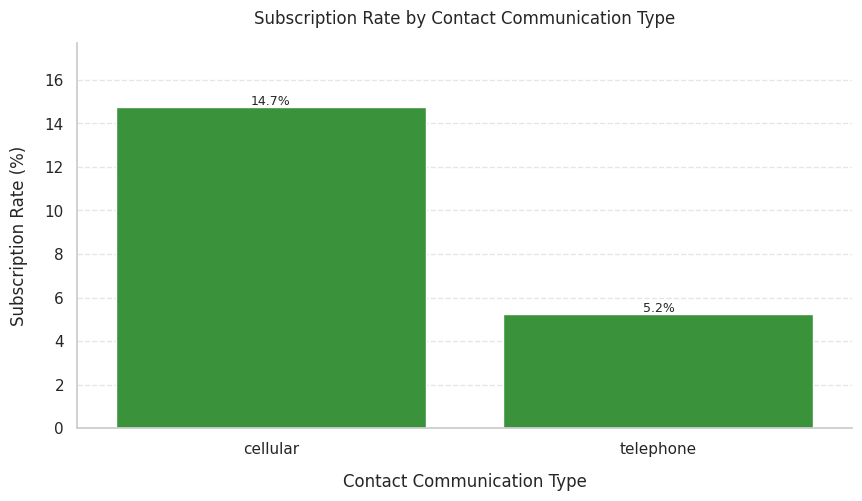

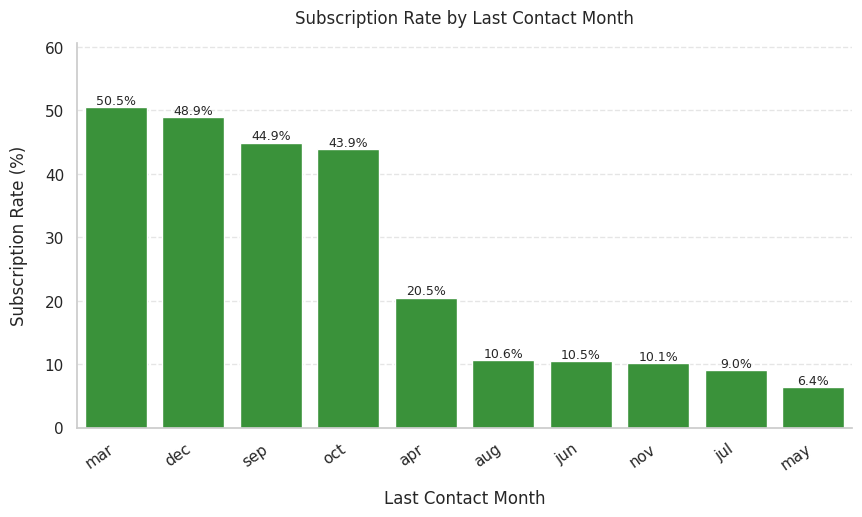

In [61]:
# Only key features included — day_of_week shows very little
# variation and adds no useful insight to the report
key_cats = ['job', 'marital', 'education', 'poutcome', 'contact', 'month']

for col in key_cats:
    fig, ax = plt.subplots(figsize=(10, 5))

    rate = (marketing.groupby(col)[TARGET]
        .apply(lambda x: (x == 'yes').mean() * 100)
        .sort_values(ascending=False)
        .reset_index())
    rate.columns = [col, 'Subscription Rate (%)']
    sns.barplot(data=rate, x=col, y='Subscription Rate (%)', color=COLOUR_NO, ax=ax)

    if marketing[col].nunique() > 4:
        plt.xticks(rotation=35, ha='right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

    plt.title(
        f'Subscription Rate by {cat_feature_names.get(col, col)}',
        pad=14)
    plt.xlabel(cat_feature_names.get(col, col), labelpad=12)
    plt.ylabel('Subscription Rate (%)', labelpad=12)
    plt.ylim(0, rate['Subscription Rate (%)'].max() * 1.2)
    sns.despine(top=True, right=True)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    plt.savefig(
        f'Subscription Rate by {cat_feature_names.get(col, col)}.png', dpi=300)
    plt.show()

    print('\n')

## Cell 15 — Age Distribution by Subscription Outcome

A KDE plot with both classes overlaid shows whether the age distribution differs between subscribers and non-subscribers.

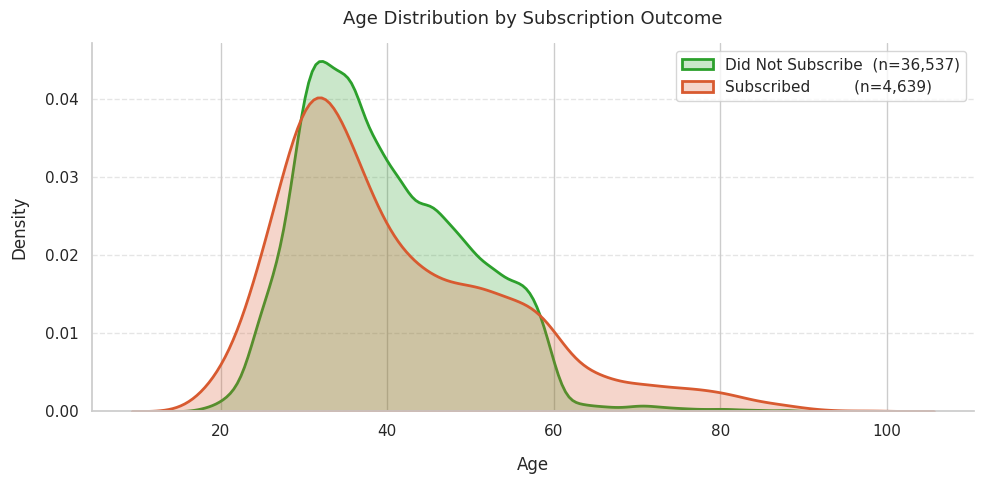

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

for outcome, colour, label in [
    ('no',  COLOUR_NO,  f'Did Not Subscribe  (n={counts["no"]:,})'),
    ('yes', COLOUR_YES, f'Subscribed         (n={counts["yes"]:,})')
]:
    subset = marketing[marketing[TARGET] == outcome]['age']
    sns.kdeplot(subset, ax=ax, color=colour, label=label, linewidth=2., fill=True, alpha=0.25)

plt.title('Age Distribution by Subscription Outcome', pad=14, fontsize=13)
plt.xlabel('Age', labelpad=12)
plt.ylabel('Density', labelpad=12)
plt.legend(fontsize=11)
sns.despine(top=True, right=True)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('fig_age_by_subscription.png', dpi=300)
plt.show()

print('\n')

## Cell 16 — Correlation Heatmap — Numerical Features (Figure 3.6)

Shows the correlation coefficient between every pair of numerical features. The upper triangle is masked to avoid repeating values. Strong correlations among the economic indicators are expected and discussed in Section 3.2.4.

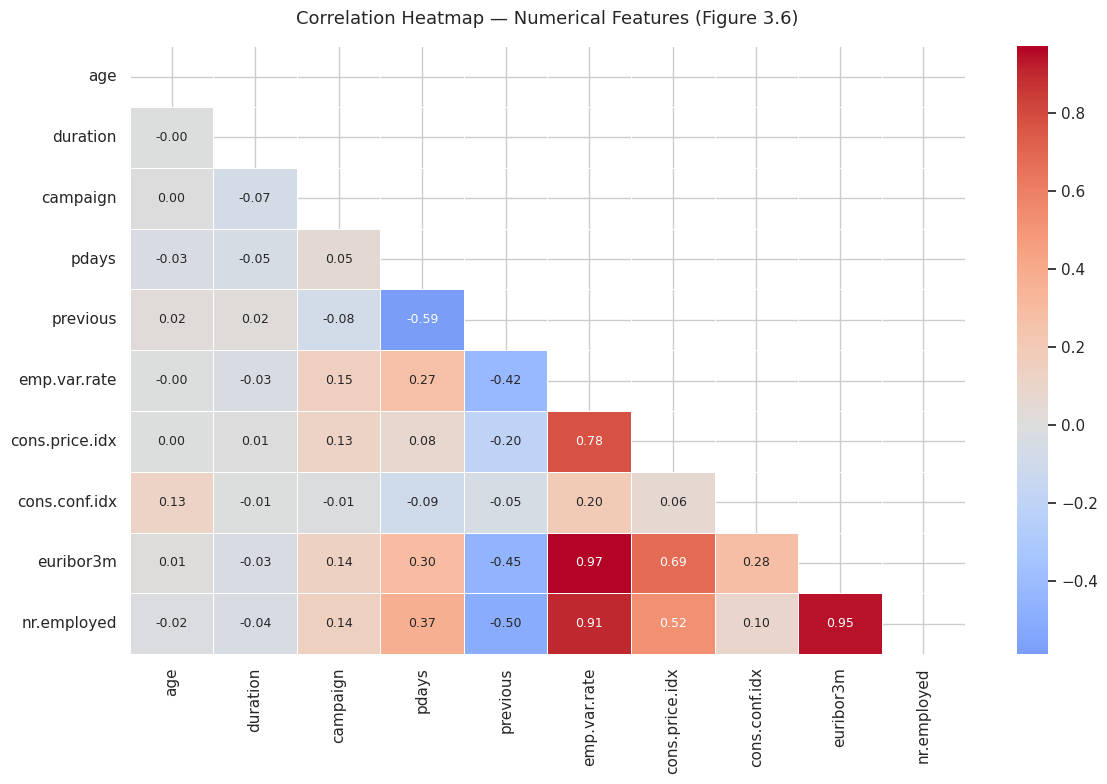

In [63]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = marketing[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

plt.title('Correlation Heatmap — Numerical Features (Figure 3.6)', pad=16, fontsize=13)
plt.tight_layout()
plt.savefig('fig_3_6_correlation_heatmap.png', dpi=300)
plt.show()



## Cell 17 — Outlier Detection (IQR Method — Table 3.3)

The IQR method is used rather than z-score because several features are heavily skewed, which violates the normality assumption z-score relies on. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.

In [64]:
print('Outlier Detection Summary — IQR Method  (Table 3.3)')
print('=' * 62)

outlier_results = {}

for col in num_features:
    Q1    = marketing[col].quantile(0.25)
    Q3    = marketing[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((marketing[col] < lower) | (marketing[col] > upper)).sum()
    pct   = round(count / len(marketing) * 100, 2)

    outlier_results[col] = {
        'Lower Bound'   : round(lower, 2),
        'Upper Bound'   : round(upper, 2),
        'Outlier Count' : count,
        'Outlier (%)'   : pct}

outlier_df = pd.DataFrame(outlier_results).T
outlier_df = outlier_df[outlier_df['Outlier Count'] > 0]

print(outlier_df.to_string())
print(f'\nTotal outlier entries: {outlier_df["Outlier Count"].sum():,.0f}')
print('\nThese records will be removed at')
print('before the preprocessing pipeline is constructed.')

Outlier Detection Summary — IQR Method  (Table 3.3)
               Lower Bound  Upper Bound  Outlier Count  Outlier (%)
age                   9.50        69.50         468.00         1.14
duration           -223.50       644.50        2963.00         7.20
campaign             -2.00         6.00        2406.00         5.84
pdays               999.00       999.00        1515.00         3.68
previous              0.00         0.00        5625.00        13.66
cons.conf.idx       -52.15       -26.95         446.00         1.08

Total outlier entries: 13,423

These records will be removed at
before the preprocessing pipeline is constructed.


## Cell 18 — Final Dataset State Summary (Table 3.1)

A complete record of the dataset at the end of Part 1. Every number here feeds into Table 3.1 of the report. The after-preprocessing version is produced at the end of Part 2.

In [65]:
no_count  = (marketing[TARGET] == 'no').sum()
yes_count = (marketing[TARGET] == 'yes').sum()

print('=' * 62)
print('  DATASET STATE SUMMARY — END OF PART 1  (Before Preprocessing)')
print('=' * 62)
print(f'  Total records (after duplicate removal) : {len(marketing):,}')
print(f'  Total features (excluding target)       : {len(marketing.columns) - 1}')
print(f'  Numerical features                      : {len(num_features)}')
print(f'  Categorical features                    : {len(cat_features)}')
print(f'  Target column                           : {TARGET}  (yes / no)')
print(f'  NaN missing values                      : {marketing.isnull().sum().sum()}')
print(f'  Unknown values present in               : 6 categorical columns')
print(f'  Duplicates removed                      : 12')
print(f'  pdays = 999 (date unknown)              : 39,661 rows')
print(f'  Class split — no                        : {no_count:,}  ({no_count/len(marketing)*100:.1f}%)')
print(f'  Class split — yes                       : {yes_count:,}  ({yes_count/len(marketing)*100:.1f}%)')
print('=' * 62)
print()
print('Part 1 complete.')
print('All EDA figures saved to the working directory.')
print('Proceed to Part 2 — Preprocessing and Feature Engineering.')

  DATASET STATE SUMMARY — END OF PART 1  (Before Preprocessing)
  Total records (after duplicate removal) : 41,176
  Total features (excluding target)       : 20
  Numerical features                      : 10
  Categorical features                    : 10
  Target column                           : subscribed  (yes / no)
  NaN missing values                      : 0
  Unknown values present in               : 6 categorical columns
  Duplicates removed                      : 12
  pdays = 999 (date unknown)              : 39,661 rows
  Class split — no                        : 36,537  (88.7%)
  Class split — yes                       : 4,639  (11.3%)

Part 1 complete.
All EDA figures saved to the working directory.
Proceed to Part 2 — Preprocessing and Feature Engineering.


## Download All Charts

Run this cell to download every saved chart from Colab at once.

In [66]:
"""from google.colab import files
import glob

all_charts = sorted(glob.glob('*.png'))
print(f'Downloading {len(all_charts)} charts...')
for chart in all_charts:
    files.download(chart)
    print(f'  Downloaded: {chart}')"""

"from google.colab import files\nimport glob\n\nall_charts = sorted(glob.glob('*.png'))\nprint(f'Downloading {len(all_charts)} charts...')\nfor chart in all_charts:\n    files.download(chart)\n    print(f'  Downloaded: {chart}')"